### **BEYOND SEGMENTS: ANALYSING PRICE SENSITIVITY AND CUSTOMER **

## LIFETIME VALUE ACROSS K-MEANS CLUSTERS FOR REVENUE OPTIMISATION

In [81]:
# Author:     Joseph Bautista
# Student ID: W2113829
# Supervisor: Deepika Deepika
# University: University of Westminster
# Dataset:    Online Retail II — UCI Machine Learning Repository

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

In [4]:
df = pd.read_excel('/content/online_retail_II.xlsx')

In [5]:
FILEPATH = '/content/online_retail_II.xlsx'
df1 = pd.read_excel(FILEPATH, sheet_name='Year 2009-2010')
df2 = pd.read_excel(FILEPATH, sheet_name='Year 2010-2011')

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data inspection

In [7]:
print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


Missing Values

In [8]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [9]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [10]:
df['Invoice'] = df['Invoice'].astype(str)

In [11]:
cancelled_sample = df[df['Invoice'].str.startswith('C')][
    ['Invoice','Customer ID','Description','Quantity','Price']].head(5)
print(cancelled_sample.to_string(index=False))

Invoice  Customer ID                   Description  Quantity  Price
C489449      16321.0      PAPER BUNTING WHITE LACE       -12   2.95
C489449      16321.0  CREAM FELT EASTER EGG BASKET        -6   1.65
C489449      16321.0 POTTING SHED SOW 'N' GROW SET        -4   4.25
C489449      16321.0            POTTING SHED TWINE        -6   2.10
C489449      16321.0    PAPER CHAIN KIT RETRO SPOT       -12   2.95


In [12]:
# Removing cancelled transactions
before = len(df)
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df['Invoice'].str.startswith('C')]
removed = before - len(df)

In [13]:
# AFTER cancelled transactions removed")
print(f"   Rows before:  {before:,}")
print(f"   Rows removed: {removed:,}")
print(f"   Rows after:   {len(df):,}")

   Rows before:  525,461
   Rows removed: 10,206
   Rows after:   515,255


Drop missing Customer IDs

In [14]:
print(f"\n   Missing Customer ID count: {df['Customer ID'].isnull().sum():,}")
print(f"   That is {df['Customer ID'].isnull().sum()/len(df)*100:.1f}% of remaining rows")
print("\n   Sample rows WITH missing Customer ID:")
missing_sample = df[df['Customer ID'].isnull()][
    ['Invoice','InvoiceDate','Description','Quantity','Price','Country']].head(5)
print(missing_sample.to_string(index=False))


   Missing Customer ID count: 107,560
   That is 20.9% of remaining rows

   Sample rows WITH missing Customer ID:
Invoice         InvoiceDate               Description  Quantity  Price        Country
 489464 2009-12-01 10:52:00              85123a mixed       -96   0.00 United Kingdom
 489463 2009-12-01 10:52:00                     short      -240   0.00 United Kingdom
 489467 2009-12-01 10:53:00               21733 mixed      -192   0.00 United Kingdom
 489521 2009-12-01 11:44:00                       NaN       -50   0.00 United Kingdom
 489525 2009-12-01 11:49:00 BLUE PULL BACK RACING CAR         1   0.55 United Kingdom


In [15]:
before = len(df)
df = df.dropna(subset=['Customer ID'])
df['Customer ID'] = df['Customer ID'].astype(int)
removed = before - len(df)

In [16]:
print(f"   Rows before:  {before:,}")
print(f"   Rows removed: {removed:,}")
print(f"   Rows after:   {len(df):,}")
print(f"\n   Verify — missing Customer IDs remaining: {df['Customer ID'].isnull().sum()}")

   Rows before:  515,255
   Rows removed: 107,560
   Rows after:   407,695

   Verify — missing Customer IDs remaining: 0


In [17]:
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


Filtering to only UK transactions

In [18]:
# Before transaction count by country (top 10)
print("\n   transaction count by country (top 10):")
country_counts = df['Country'].value_counts().head(10)
print(country_counts.to_string())
print(f"\n   Total non-UK rows to remove: "
      f"{(df['Country'] != 'United Kingdom').sum():,}")


   transaction count by country (top 10):
Country
United Kingdom    370951
EIRE                8507
Germany             7661
France              5470
Netherlands         2730
Spain               1235
Switzerland         1170
Belgium             1038
Portugal             984
Sweden               868

   Total non-UK rows to remove: 36,744


In [19]:
before = len(df)
df = df[df['Country'] == 'United Kingdom']
removed = before - len(df)

In [20]:
# After removing non-UK transactions
print(f"   Rows before:  {before:,}")
print(f"   Rows removed: {removed:,}")
print(f"   Rows after:   {len(df):,}")

   Rows before:  407,695
   Rows removed: 36,744
   Rows after:   370,951


Removing invalid Prices and Quantitites

In [21]:
print(f"\n   BEFORE:")
print(f"   Rows with Price <= 0:    {(df['Price'] <= 0).sum():,}")
print(f"   Rows with Quantity <= 0: {(df['Quantity'] <= 0).sum():,}")
print("\n   Sample rows with zero or negative Price:")
invalid_price = df[df['Price'] <= 0][
    ['Invoice','Description','Quantity','Price','Country']].head(5)
print(invalid_price.to_string(index=False) if len(invalid_price) > 0
      else "   None found")
print("\n   Sample rows with zero or negative Quantity:")
invalid_qty = df[df['Quantity'] <= 0][
    ['Invoice','Description','Quantity','Price','Country']].head(5)
print(invalid_qty.to_string(index=False) if len(invalid_qty) > 0
      else "   None found")


   BEFORE:
   Rows with Price <= 0:    22
   Rows with Quantity <= 0: 0

   Sample rows with zero or negative Price:
Invoice                    Description  Quantity  Price        Country
 489825             6 RIBBONS EMPIRE          12    0.0 United Kingdom
 489998            DOOR MAT FAIRY CAKE         2    0.0 United Kingdom
 490727                         Manual         1    0.0 United Kingdom
 490961 CHRISTMAS PUDDING TRINKET POT          1    0.0 United Kingdom
 490961   CHRISTMAS CRAFT WHITE FAIRY         12    0.0 United Kingdom

   Sample rows with zero or negative Quantity:
   None found


In [22]:
before = len(df)
df = df[df['Price'] > 0]
df = df[df['Quantity'] > 0]
removed = before - len(df)

In [23]:
# After invalid rows removed
print(f"   Rows before:  {before:,}")
print(f"   Rows removed: {removed:,}")
print(f"   Rows after:   {len(df):,}")
print(f"\n   Verify — Price min: £{df['Price'].min():.2f}  "
      f"Quantity min: {df['Quantity'].min()}")


   Rows before:  370,951
   Rows removed: 22
   Rows after:   370,929

   Verify — Price min: £0.00  Quantity min: 1


Validate Clean dataset

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSpend']  = df['Price'] * df['Quantity']

In [25]:
# Dimensions: rows, columns
print(len(df))
print(df.shape)

370929
(370929, 9)


In [26]:
# Coverage:
print(f"   Unique customers:  {df['Customer ID'].nunique():,}")
print(f"   Unique products:   {df['StockCode'].nunique():,}")
print(f"   Unique invoices:   {df['Invoice'].nunique():,}")
print(f"   Date range:        {df['InvoiceDate'].min().date()} "
      f"to {df['InvoiceDate'].max().date()}")
print(f"   Total revenue:     £{df['TotalSpend'].sum():,.2f}")

   Unique customers:  3,969
   Unique products:   4,001
   Unique invoices:   17,612
   Date range:        2009-12-01 to 2010-12-09
   Total revenue:     £7,414,755.96


In [27]:
# Data Quality Checks
print(f"   Missing values:          {df.isnull().sum().sum()}")
print(f"   Cancelled invoices (C):  "
      f"{df['Invoice'].str.startswith('C').sum()}")
print(f"   Zero/negative Price:     {(df['Price'] <= 0).sum()}")
print(f"   Zero/negative Quantity:  {(df['Quantity'] <= 0).sum()}")
print(f"   Non-UK transactions:     "
      f"{(df['Country'] != 'United Kingdom').sum()}")

   Missing values:          0
   Cancelled invoices (C):  0
   Zero/negative Price:     0
   Zero/negative Quantity:  0
   Non-UK transactions:     0


In [28]:
print(f"\n  Price range:  £{df['Price'].min():.2f} to £{df['Price'].max():.2f}")
print(f"  Qty range:    {df['Quantity'].min()} to {df['Quantity'].max()}")


  Price range:  £0.00 to £10953.50
  Qty range:    1 to 10000


Cleaning Summary

In [29]:
print(f"   Raw rows:    1,067,371")
print(f"   Clean rows:  {len(df):,}")
print(f"   Removed:     {1067371 - len(df):,} "
      f"({(1067371 - len(df))/1067371*100:.1f}%)")

   Raw rows:    1,067,371
   Clean rows:  370,929
   Removed:     696,442 (65.2%)


In [30]:
# Dimensions: rows, columns
print(len(df))
print(df.shape)

370929
(370929, 9)


In [31]:
# Sample of clean data
df[['Invoice','Customer ID','Description',
    'Quantity','Price','TotalSpend',
    'InvoiceDate','Country']].head(5)

,Invoice,Customer ID,Description,Quantity,Price,TotalSpend,InvoiceDate,Country
0,489434,13085,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.4,2009-12-01 07:45:00,United Kingdom
1,489434,13085,PINK CHERRY LIGHTS,12,6.75,81.0,2009-12-01 07:45:00,United Kingdom
2,489434,13085,WHITE CHERRY LIGHTS,12,6.75,81.0,2009-12-01 07:45:00,United Kingdom
3,489434,13085,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,100.8,2009-12-01 07:45:00,United Kingdom
4,489434,13085,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,30.0,2009-12-01 07:45:00,United Kingdom


### Feature Engineering



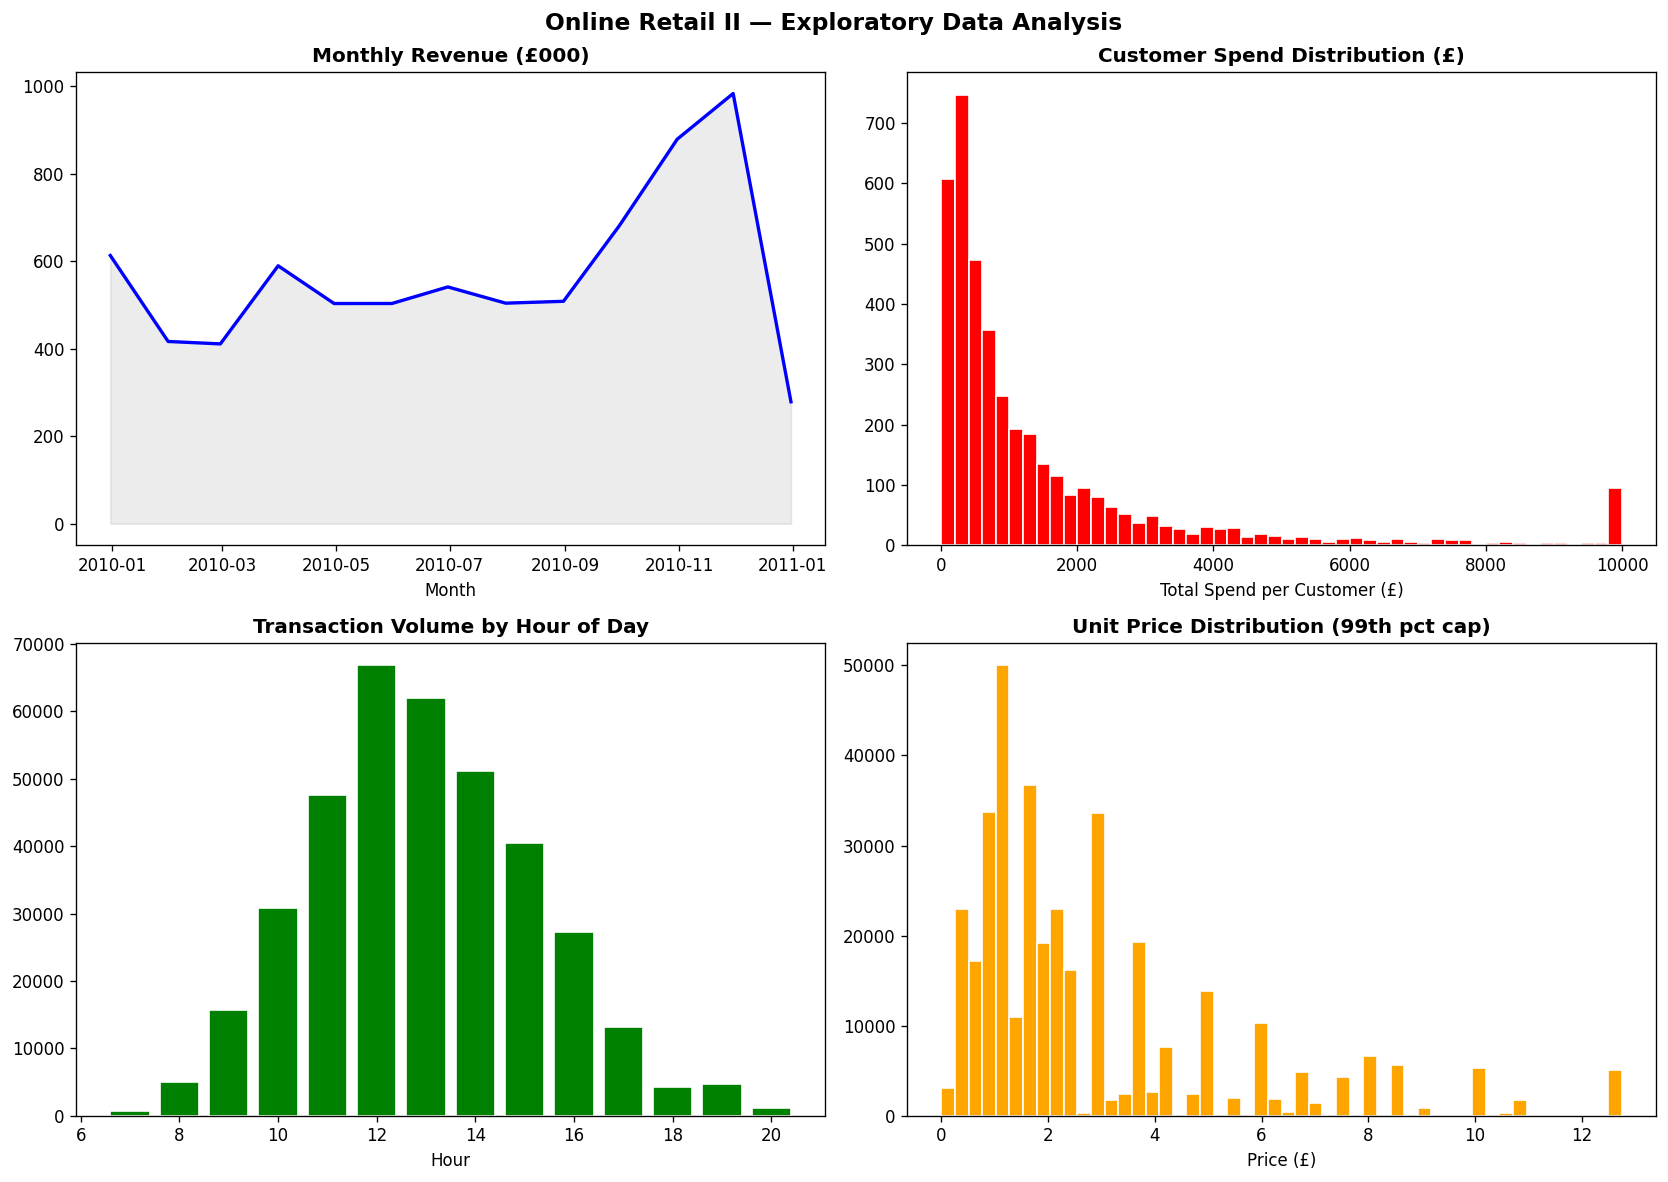

In [53]:
# Exploratory Data Analysis
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] =120

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Online Retail II — Exploratory Data Analysis',
             fontsize=14, fontweight='bold')

# Monthly revenue trend
rev_time = df.set_index('InvoiceDate').resample('ME')['TotalSpend'].sum() / 1000
axes[0,0].plot(rev_time.index, rev_time.values, color='blue', linewidth=2)
axes[0,0].fill_between(rev_time.index, rev_time.values, alpha=0.15, color='grey')
axes[0,0].set_title('Monthly Revenue (£000)', fontweight='bold')
axes[0,0].set_xlabel('Month')

# Distribution of total spend per customer
axes[0,1].hist(df.groupby('Customer ID')['TotalSpend'].sum().clip(upper=10000),
    bins=50, color='red', edgecolor='white'
)
axes[0,1].set_title('Customer Spend Distribution (£)', fontweight='bold')
axes[0,1].set_xlabel('Total Spend per Customer (£)')

# Transaction volume by hour
df['Hour'] = df['InvoiceDate'].dt.hour
hour_counts = df.groupby('Hour').size()
axes[1,0].bar(hour_counts.index, hour_counts.values,
              color='green', edgecolor='white')
axes[1,0].set_title('Transaction Volume by Hour of Day', fontweight='bold')
axes[1,0].set_xlabel('Hour')

# Price distribution (capped at 99th percentile)
price_cap = df['Price'].quantile(0.99)
axes[1,1].hist(df[df['Price'] <= price_cap]['Price'], bins=50,
               color='orange', edgecolor='white')
axes[1,1].set_title('Unit Price Distribution (99th pct cap)', fontweight='bold')
axes[1,1].set_xlabel('Price (£)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# RFM framework



In [33]:
# Recency
SNAPSHOT_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"   Snapshot date: {SNAPSHOT_DATE.date()}")

recency = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency.columns = ['Customer ID', 'LastPurchase']
recency['Recency'] = (SNAPSHOT_DATE - recency['LastPurchase']).dt.days

   Snapshot date: 2010-12-10


In [34]:
print(f"   Min:  {recency['Recency'].min()} days")
print(f"   Max:  {recency['Recency'].max()} days")
print(f"   Mean: {recency['Recency'].mean():.1f} days")
recency.head()

   Min:  1 days
   Max:  374 days
   Mean: 91.1 days


,Customer ID,LastPurchase,Recency
0,12346,2010-06-28 13:53:00,165
1,12608,2010-10-31 10:49:00,40
2,12745,2010-08-10 10:14:00,122
3,12746,2010-06-17 10:41:00,176
4,12747,2010-12-05 15:38:00,5


In [35]:
# Frequency
frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']

In [36]:
print(f"   Min:  {frequency['Frequency'].min()} invoices")
print(f"   Max:  {frequency['Frequency'].max()} invoices")
print(f"   Mean: {frequency['Frequency'].mean():.1f} invoices")
frequency.head()

   Min:  1 invoices
   Max:  155 invoices
   Mean: 4.4 invoices


,Customer ID,Frequency
0,12346,11
1,12608,1
2,12745,2
3,12746,1
4,12747,16


In [37]:
# Monetary Value
monetary = df.groupby('Customer ID')['TotalSpend'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']

In [38]:
print(f"   Min:  £{monetary['Monetary'].min():.2f}")
print(f"   Max:  £{monetary['Monetary'].max():,.2f}")
print(f"   Mean: £{monetary['Monetary'].mean():.2f}")
monetary.head()

   Min:  £2.95
   Max:  £349,164.35
   Mean: £1868.17


,Customer ID,Monetary
0,12346,372.86
1,12608,415.79
2,12745,723.85
3,12746,254.55
4,12747,5080.53


RFM table

In [39]:
rfm = recency[['Customer ID', 'Recency']].merge(
      frequency, on='Customer ID').merge(
      monetary,  on='Customer ID')

In [40]:
# Limiting outliers at 99th percentile
for col in ['Recency', 'Frequency', 'Monetary']:
    p99 = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=p99)

In [41]:
print(f"   Customers: {len(rfm):,}")
print(rfm.describe().round(2))
rfm.head()

   Customers: 3,969
       Customer ID  Recency  Frequency  Monetary
count      3969.00  3969.00    3969.00   3969.00
mean      15561.41    91.06       4.16   1584.60
std        1582.10    96.97       4.91   2742.14
min       12346.00     1.00       1.00      2.95
25%       14201.00    18.00       1.00    304.20
50%       15577.00    52.00       2.00    669.91
75%       16941.00   136.00       5.00   1655.64
max       18287.00   368.00      31.00  19349.12


,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12608,40,1,415.79
2,12745,122,2,723.85
3,12746,176,1,254.55
4,12747,5,16,5080.53


# Customer Lifetime Value (CLV)

In [42]:
clv = df.groupby('Customer ID').agg(
    Total_Spend    = ('TotalSpend',   'sum'),
    Num_Invoices   = ('Invoice',      'nunique'),
    First_Purchase = ('InvoiceDate',  'min'),
    Last_Purchase  = ('InvoiceDate',  'max')
).reset_index()

In [43]:
clv['Avg_Order_Value']       = clv['Total_Spend'] / clv['Num_Invoices']
clv['Lifespan_Months']       = ((clv['Last_Purchase'] - clv['First_Purchase']
                                 ).dt.days / 30).clip(lower=1)
clv['Purchase_Freq_Monthly'] = clv['Num_Invoices'] / clv['Lifespan_Months']
clv['CLV']                   = (clv['Avg_Order_Value']
                                 * clv['Purchase_Freq_Monthly']
                                 * clv['Lifespan_Months'])

In [44]:
rfm = rfm.merge(clv[['Customer ID', 'CLV', 'Avg_Order_Value',
                       'Lifespan_Months']], on='Customer ID', how='left')

In [45]:
print(f"   Average CLV: £{rfm['CLV'].mean():.2f}")
print(f"   Median CLV:  £{rfm['CLV'].median():.2f}")
print(f"   Max CLV:     £{rfm['CLV'].max():,.2f}")
rfm.head()

   Average CLV: £1868.17
   Median CLV:  £669.91
   Max CLV:     £349,164.35


,Customer ID,Recency,Frequency,Monetary,CLV,Avg_Order_Value,Lifespan_Months
0,12346,165,11,372.86,372.86,33.896364,6.533333
1,12608,40,1,415.79,415.79,415.790000,1.000000
2,12745,122,2,723.85,723.85,361.925000,2.900000
3,12746,176,1,254.55,254.55,254.550000,1.000000
4,12747,5,16,5080.53,5080.53,317.533125,12.100000


Scale RFM with StandardScaler

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [48]:
print(f"   Recency    — mean: {rfm_scaled[:,0].mean():.4f}, std: {rfm_scaled[:,0].std():.4f}")
print(f"   Frequency  — mean: {rfm_scaled[:,1].mean():.4f}, std: {rfm_scaled[:,1].std():.4f}")
print(f"   Monetary   — mean: {rfm_scaled[:,2].mean():.4f}, std: {rfm_scaled[:,2].std():.4f}")

   Recency    — mean: 0.0000, std: 1.0000
   Frequency  — mean: 0.0000, std: 1.0000
   Monetary   — mean: -0.0000, std: 1.0000


RFM Distribution Plots

In [49]:
import numpy as np

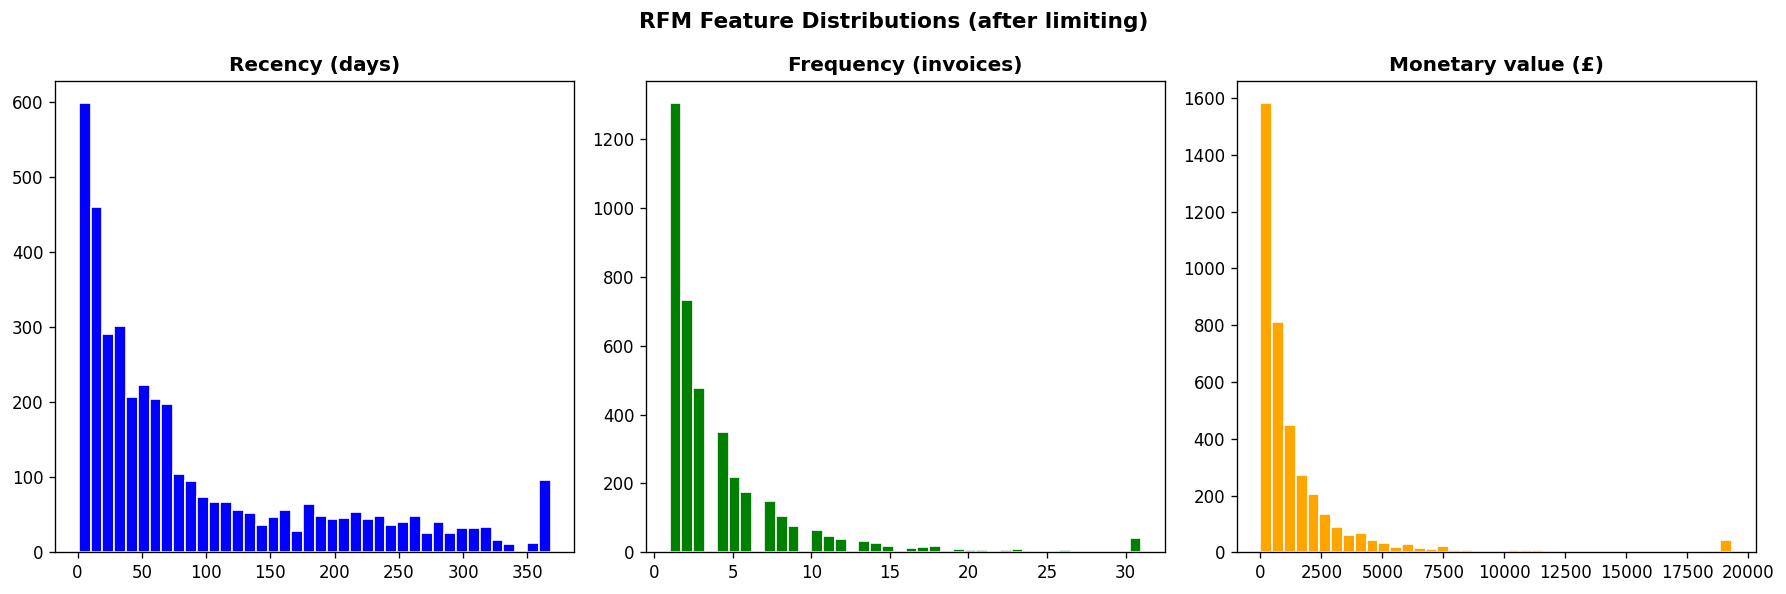

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Feature Distributions (after limiting)',
             fontsize=13, fontweight='bold')

axes[0].hist(rfm['Recency'],   bins=40, color='blue', edgecolor='white')
axes[0].set_title('Recency (days)', fontweight='bold')

axes[1].hist(rfm['Frequency'], bins=40, color='green', edgecolor='white')
axes[1].set_title('Frequency (invoices)', fontweight='bold')

axes[2].hist(rfm['Monetary'],  bins=40, color='orange', edgecolor='white')
axes[2].set_title('Monetary value (£)', fontweight='bold')

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Heatmap

In [54]:
import seaborn as sns

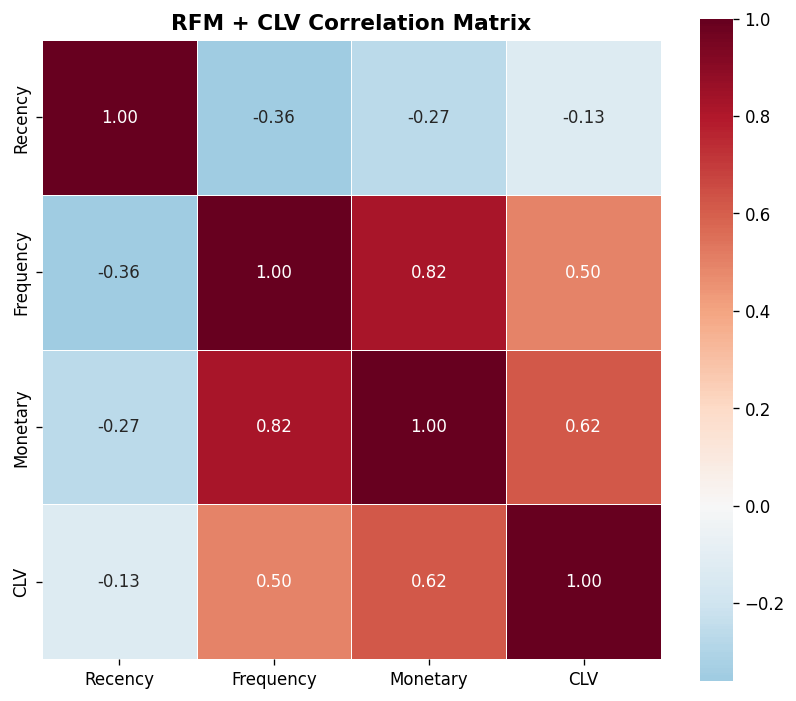

In [55]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = rfm[['Recency', 'Frequency', 'Monetary', 'CLV']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('RFM + CLV Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## K-means CLustering

Elbow method

In [56]:
from sklearn.cluster import KMeans

In [68]:
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42,n_init=15)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    print(f"   K={k}: inertia = {km.inertia_:,.0f}")

   K=2: inertia = 7,086
   K=3: inertia = 3,928
   K=4: inertia = 2,573
   K=5: inertia = 2,054
   K=6: inertia = 1,697
   K=7: inertia = 1,479
   K=8: inertia = 1,303
   K=9: inertia = 1,167
   K=10: inertia = 1,061


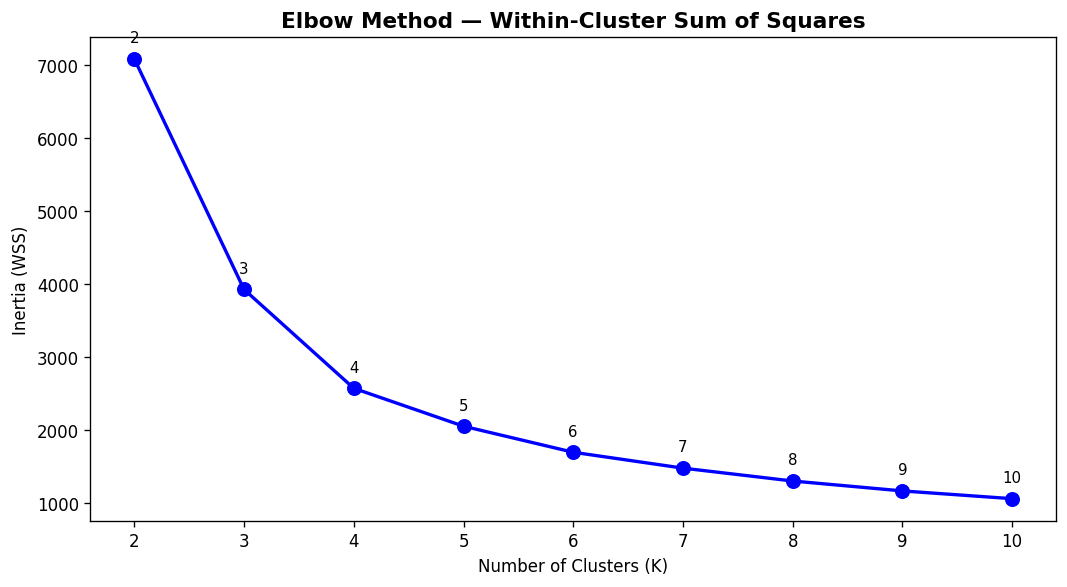

In [69]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Within-Cluster Sum of Squares', fontweight='bold', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WSS)')
for k, v in zip(k_range, inertias):
    plt.annotate(str(k), (k, v), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

Silhouette Scores

In [60]:
from sklearn.metrics import silhouette_score

In [61]:
silhouettes = []
for k in k_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=15)
    labs = km.fit_predict(rfm_scaled)
    sil  = silhouette_score(rfm_scaled, labs,
                            sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"   K={k}: silhouette = {sil:.4f}")

best_k = list(k_range)[silhouettes.index(max(silhouettes))]

   K=2: silhouette = 0.6529
   K=3: silhouette = 0.5343
   K=4: silhouette = 0.5294
   K=5: silhouette = 0.4673
   K=6: silhouette = 0.4456
   K=7: silhouette = 0.4228
   K=8: silhouette = 0.4190
   K=9: silhouette = 0.3706
   K=10: silhouette = 0.3858


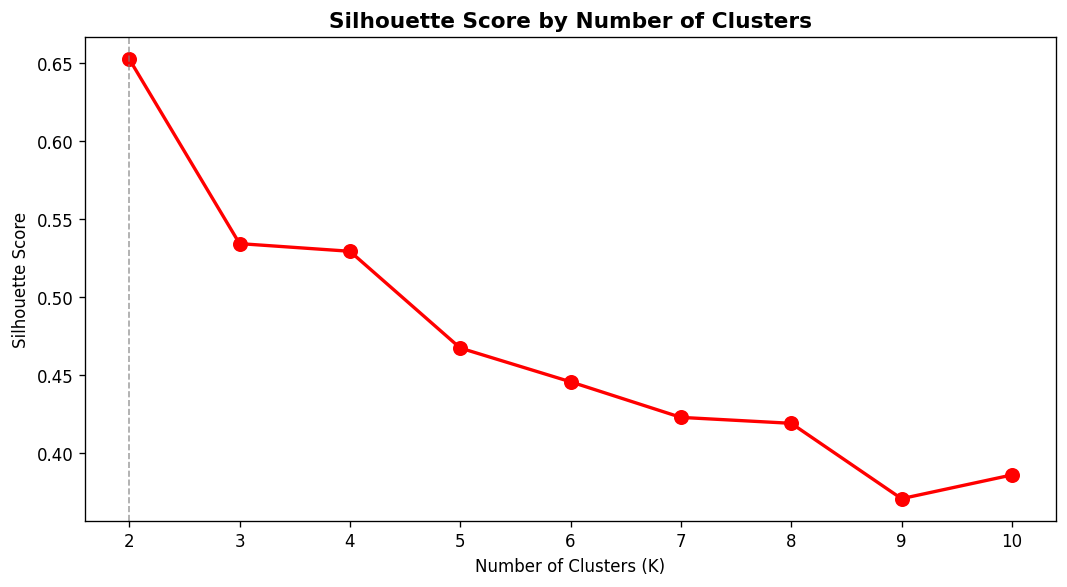

In [62]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), silhouettes, 'ro-', linewidth=2, markersize=8)
plt.axvline(best_k, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.title('Silhouette Score by Number of Clusters', fontweight='bold', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

Select optimal K and apply K-means

In [67]:
K = 4
km_final      = KMeans(n_clusters=K, random_state=42, n_init=15)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

final_sil = silhouette_score(rfm_scaled, rfm['Cluster'],
                              sample_size=5000, random_state=42)
print(f"   Final silhouette score: {final_sil:.4f}")
print(f"\n   Cluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

   Final silhouette score: 0.5294

   Cluster sizes:
Cluster
0     918
1    2377
2      98
3     576
Name: count, dtype: int64


Profile and label clusters

In [71]:
profile = rfm.groupby('Cluster').agg(
    Recency_mean   = ('Recency',    'mean'),
    Frequency_mean = ('Frequency',  'mean'),
    Monetary_mean  = ('Monetary',   'mean'),
    CLV_mean       = ('CLV',        'mean'),
    Size           = ('Customer ID','count')
).round(2)
print(profile.to_string())

         Recency_mean  Frequency_mean  Monetary_mean  CLV_mean  Size
Cluster                                                             
0              247.70            1.59         479.04    479.04   918
1               49.33            2.80         864.11    864.11  2377
2               14.89           24.45       15092.75  26577.02    98
3               26.59           10.39        4021.63   4021.63   576


In [75]:
# Auto-label based on RFM profile ranking
p         = profile.copy()
rec_rank  = p['Recency_mean'].rank()
freq_rank = p['Frequency_mean'].rank(ascending=False)
mon_rank  = p['Monetary_mean'].rank(ascending=False)
score     = rec_rank + freq_rank + mon_rank

labels    = {}
sorted_clusters = score.sort_values().index.tolist()
label_names = ['Champions', 'Loyal Customers', 'At-Risk', 'Lost Customers']
for cluster, name in zip(sorted_clusters, label_names):
    labels[cluster] = name

rfm['Segment'] = rfm['Cluster'].map(labels)

print(f"\n Segment labels assigned: {labels}")
print(f"\n Segment sizes:")
print(rfm['Segment'].value_counts())



 Segment labels assigned: {2: 'Champions', 3: 'Loyal Customers', 1: 'At-Risk', 0: 'Lost Customers'}

 Segment sizes:
Segment
At-Risk            2377
Lost Customers      918
Loyal Customers     576
Champions            98
Name: count, dtype: int64


K-means Cluster Scatter Plot

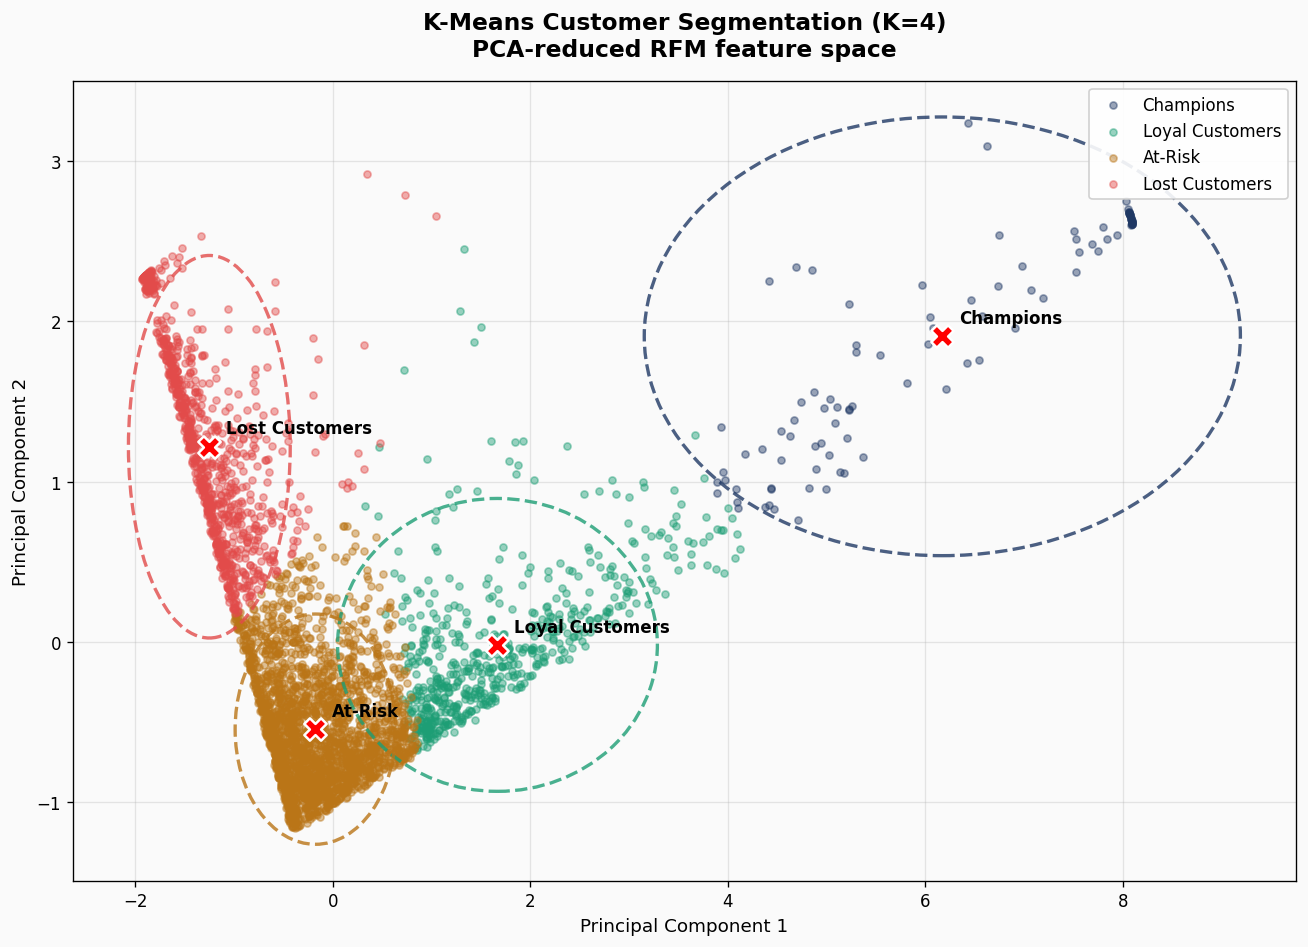

In [80]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import numpy as np

# Reduce RFM to 2D using PCA for visualisation
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_scaled)

# Get centroids in 2D
centroids_2d = pca.transform(km_final.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

COLORS = {
    'Champions':      '#1F3864',
    'Loyal Customers':'#1D9E75',
    'At-Risk':        '#BA7517',
    'Lost Customers': '#E24B4A'
}

order = ['Champions','Loyal Customers','At-Risk','Lost Customers']

# Plot each segment
for seg in order:
    mask = rfm['Segment'] == seg
    ax.scatter(rfm_2d[mask, 0], rfm_2d[mask, 1],
               color=COLORS[seg], alpha=0.45,
               s=18, label=seg, zorder=2)

# Draw ellipses around each cluster
from matplotlib.patches import Ellipse
for seg in order:
    mask = rfm['Segment'] == seg
    points = rfm_2d[mask]
    x_mean, y_mean = points[:,0].mean(), points[:,1].mean()
    x_std,  y_std  = points[:,0].std(),  points[:,1].std()

    ellipse = Ellipse(
        xy=(x_mean, y_mean),
        width=x_std * 4,
        height=y_std * 4,
        edgecolor=COLORS[seg],
        facecolor='none',
        linewidth=2,
        linestyle='--',
        zorder=3,
        alpha=0.8
    )
    ax.add_patch(ellipse)

# Plot centroids as red X marks — just like the example
for i, seg in enumerate(order):
    mask = rfm['Segment'] == seg
    points = rfm_2d[mask]
    cx, cy = points[:,0].mean(), points[:,1].mean()
    ax.scatter(cx, cy, color='red', marker='X',
               s=180, zorder=5, linewidths=1.5,
               edgecolors='white')
    ax.annotate(seg, (cx, cy),
                textcoords='offset points',
                xytext=(10, 8),
                fontsize=10,
                fontweight='bold',
                color='black')

ax.set_title('K-Means Customer Segmentation (K=4)\n'
             'PCA-reduced RFM feature space',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Principal Component 1', fontsize=11)
ax.set_ylabel('Principal Component 2', fontsize=11)
ax.legend(fontsize=10, loc='upper right',
          framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_scatter_pca.png', dpi=150,
            bbox_inches='tight')
plt.show()

RFM Scatter plots

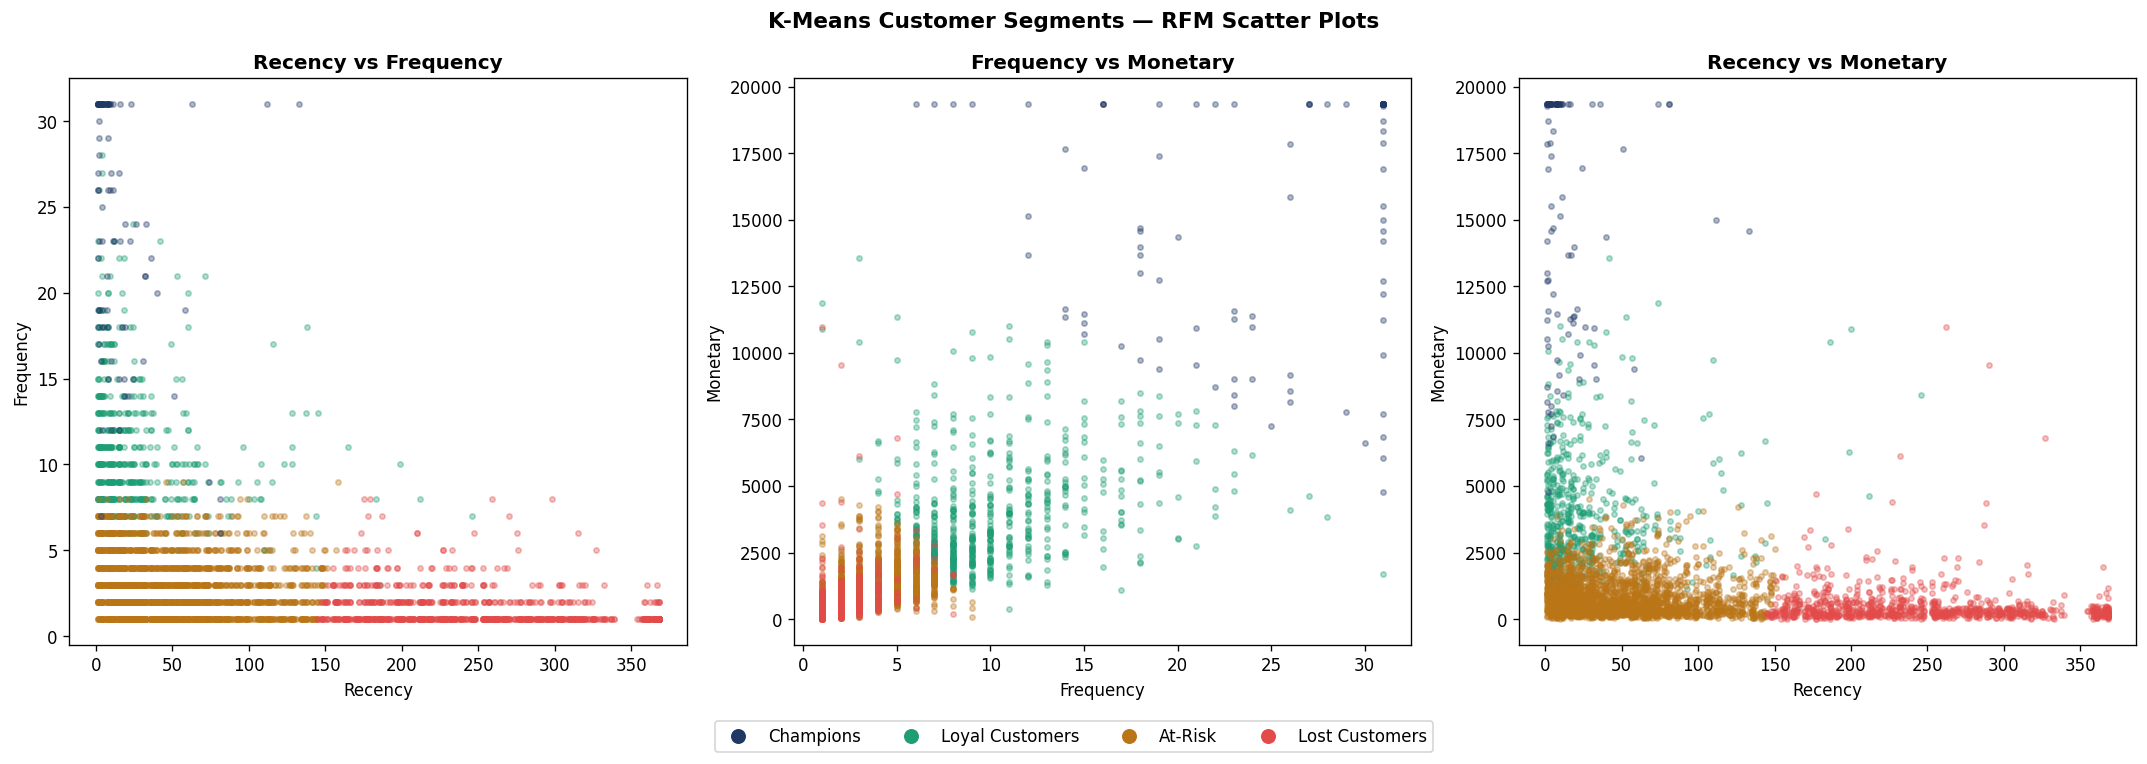

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('K-Means Customer Segments — RFM Scatter Plots',
             fontsize=13, fontweight='bold')

pairs = [('Recency','Frequency'), ('Frequency','Monetary'), ('Recency','Monetary')]
for ax, (x, y) in zip(axes, pairs):
    for seg in rfm['Segment'].unique():
        g = rfm[rfm['Segment'] == seg]
        ax.scatter(g[x], g[y], label=seg, color=COLORS[seg], alpha=0.35, s=10)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontweight='bold')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=COLORS[s], markersize=10, label=s)
           for s in COLORS]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

CLV comparison by segment

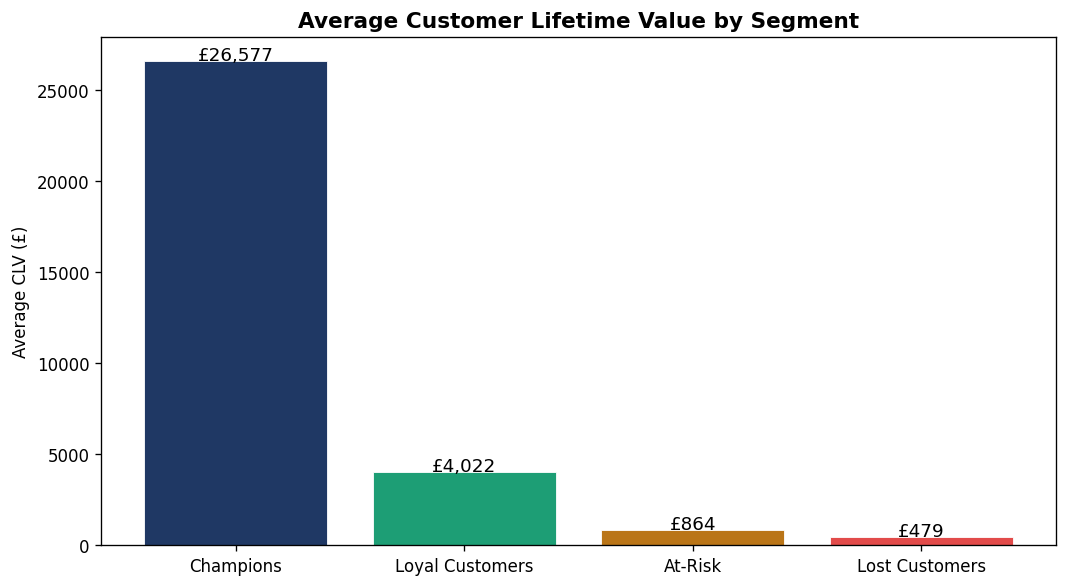

In [83]:
order   = ['Champions', 'Loyal Customers', 'At-Risk', 'Lost Customers']
clv_seg = rfm.groupby('Segment')['CLV'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(clv_seg.index, clv_seg.values,
              color=[COLORS[s] for s in clv_seg.index],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, clv_seg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50, f'£{val:,.0f}',
            ha='center', fontsize=11)
ax.set_title('Average Customer Lifetime Value by Segment',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Average CLV (£)')

plt.tight_layout()
plt.savefig('clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()